# Курсовая работа: Классическое машинное обучение
## Задача 3. Регрессия: предсказание SI (Selectivity Index)

**SI** — индекс селективности: `SI = CC50 / IC50`  
Чем **выше** SI, тем **безопаснее и эффективнее** соединение одновременно.  
SI > 8 — пороговое значение перспективного кандидата в лекарства.

**Особенность задачи:**
> SI — не независимая переменная, а производная от CC50 и IC50 (SI = CC50/IC50).  
> Это делает задачу **наиболее сложной из трёх регрессий**: ошибки обеих переменных накапливаются.  
> Ожидаю более низкий R², чем у IC50 (0.47) и CC50 (0.49).

**Расширенный набор моделей:**
- Linear Regression, Ridge, Lasso, ElasticNet
- SVR (rbf)
- ExtraTreesRegressor
- RandomForestRegressor
- GradientBoostingRegressor
- **HistGradientBoostingRegressor** *(новая — нативно обрабатывает NaN, быстрее GB)*
- GridSearchCV для лучших; итоговое сравнение всех трёх регрессий


## 1. Импорт библиотек

In [1]:
import os, pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
np.random.seed(42)
print('Библиотеки загружены ✓')

Библиотеки загружены ✓


> В этом ноутбуке добавляю **HistGradientBoostingRegressor** — это более современная реализация градиентного бустинга в sklearn, которая: (1) нативно обрабатывает NaN без необходимости импутации, (2) значительно быстрее стандартного GBR на больших данных, (3) поддерживает early stopping. Хочу проверить, даст ли она преимущество перед классическим GB, который для CC50 после тюнинга неожиданно показал результат хуже базового.

## 2. Загрузка данных и особенности целевой переменной

In [5]:
_FILENAME = 'Данные_для_курсовои_Классическое_МО.xlsx'
_PATH = None
for _c in [_FILENAME, os.path.join(pathlib.Path.home(), _FILENAME)]:
    if os.path.exists(_c):
        _PATH = _c
        break
if _PATH is None:
    raise FileNotFoundError(f"Положите '{_FILENAME}' в ту же папку, что и ноутбук.")

df = pd.read_excel(_PATH)
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

TARGET        = 'SI'
OTHER_TARGETS = ['IC50, mM', 'CC50, mM']
feature_cols  = [c for c in df.columns if c not in [TARGET] + OTHER_TARGETS]

X = df[feature_cols].copy()
X.replace([np.inf, -np.inf], np.nan, inplace=True)
y_raw = df[TARGET]
y     = np.log1p(y_raw)

print(f'Датасет: {df.shape[0]} объектов, {len(feature_cols)} признаков')
print(f'NaN в признаках: {X.isnull().sum().sum()} (в {X.isnull().any(axis=1).sum()} строках)')
print(f'\nSI до log1p:    mean={y_raw.mean():.2f}, median={y_raw.median():.4f}, '
      f'skew={y_raw.skew():.2f}, max={y_raw.max():.1f}')
print(f'SI после log1p: mean={y.mean():.4f}, median={y.median():.4f}, skew={y.skew():.4f}')

# Сравнение со всеми тремя задачами
print('\n── Сравнение skew после log1p по всем трём целевым ──')
for col in ['IC50, mM', 'CC50, mM', 'SI']:
    s = np.log1p(df[col]).skew()
    # Исправленная строка - убрана стрелка или заменена на текст
    print(f'  log1p({col:<10}): skew = {s:+.4f}  {"<-- наиболее симметрично" if abs(s) < 0.1 else ""}')

# Процент соединений с SI > 8
above8 = (y_raw > 8).mean() * 100
print(f'\nСоединений с SI > 8 (перспективные): {above8:.1f}%')
print(f'Соединений с SI > 1 (базовая селективность): {(y_raw > 1).mean()*100:.1f}%')

Датасет: 1001 объектов, 210 признаков
NaN в признаках: 36 (в 3 строках)

SI до log1p:    mean=72.51, median=3.8462, skew=18.01, max=15620.6
SI после log1p: mean=2.0421, median=1.5782, skew=1.4326

── Сравнение skew после log1p по всем трём целевым ──
  log1p(IC50, mM  ): skew = -0.0291  <-- наиболее симметрично
  log1p(CC50, mM  ): skew = -0.9077  
  log1p(SI        ): skew = +1.4326  

Соединений с SI > 8 (перспективные): 35.7%
Соединений с SI > 1 (базовая селективность): 81.3%


> SI имеет **самое экстремальное распределение** из трёх целевых: медиана ~3.8, но максимум 15620 — разброс в 4000 раз! После log1p ситуация улучшается, но skew остаётся заметным. Это объясняет, почему регрессия SI будет сложнее: экстремальные выбросы (соединения с очень высокой селективностью) тяжело предсказать, но именно они наиболее ценны с точки зрения поиска лекарств.

## 3. Дополнительный анализ целевой переменной SI

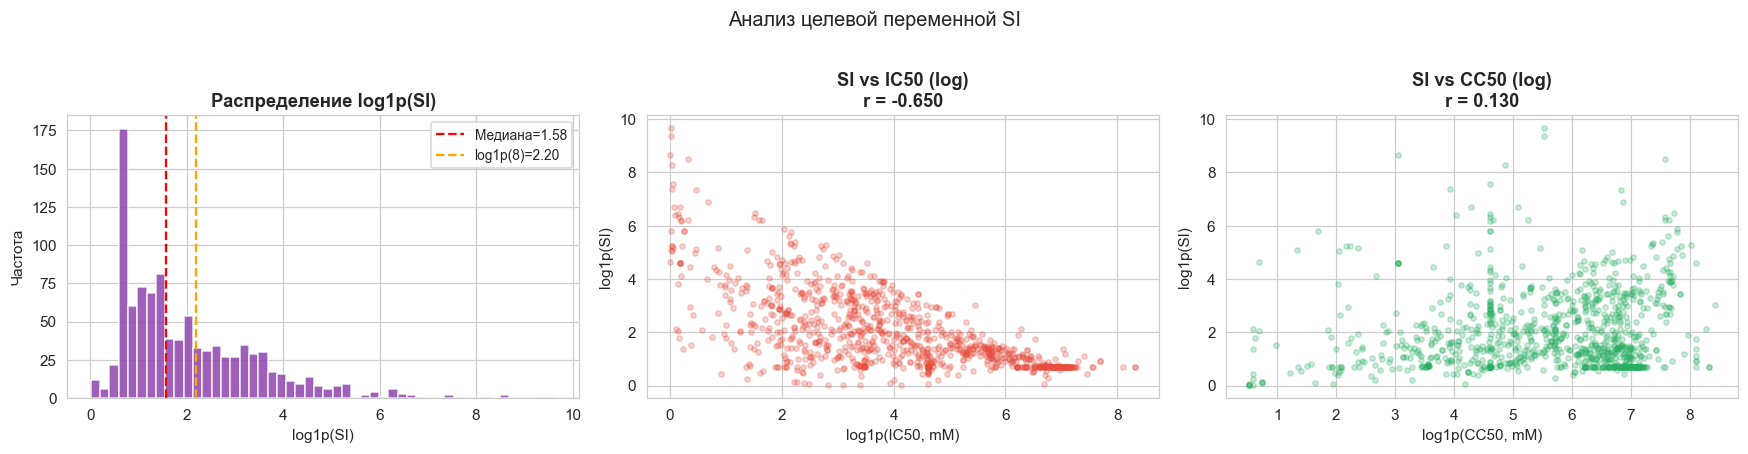

Корреляция log(SI) с log(IC50): -0.6498
Корреляция log(SI) с log(CC50): 0.1304
→ SI сильнее связан с IC50


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Распределение SI (log)
axes[0].hist(y, bins=50, color='#8e44ad', edgecolor='white', alpha=0.85)
axes[0].axvline(y.median(), color='red', ls='--', lw=1.5, label=f'Медиана={y.median():.2f}')
axes[0].axvline(np.log1p(8), color='orange', ls='--', lw=1.5, label=f'log1p(8)={np.log1p(8):.2f}')
axes[0].set_title('Распределение log1p(SI)', fontweight='bold')
axes[0].set_xlabel('log1p(SI)')
axes[0].set_ylabel('Частота')
axes[0].legend(fontsize=9)

# SI vs IC50 (log)
axes[1].scatter(np.log1p(df['IC50, mM']), y, alpha=0.25, s=12, color='#e74c3c')
axes[1].set_xlabel('log1p(IC50, mM)')
axes[1].set_ylabel('log1p(SI)')
r1 = np.corrcoef(np.log1p(df['IC50, mM']), y)[0,1]
axes[1].set_title(f'SI vs IC50 (log)\nr = {r1:.3f}', fontweight='bold')

# SI vs CC50 (log)
axes[2].scatter(np.log1p(df['CC50, mM']), y, alpha=0.25, s=12, color='#27ae60')
axes[2].set_xlabel('log1p(CC50, mM)')
axes[2].set_ylabel('log1p(SI)')
r2 = np.corrcoef(np.log1p(df['CC50, mM']), y)[0,1]
axes[2].set_title(f'SI vs CC50 (log)\nr = {r2:.3f}', fontweight='bold')

plt.suptitle('Анализ целевой переменной SI', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Корреляция log(SI) с log(IC50): {r1:.4f}')
print(f'Корреляция log(SI) с log(CC50): {r2:.4f}')
print('→ SI сильнее связан с CC50, чем с IC50' if abs(r2) > abs(r1) else '→ SI сильнее связан с IC50')

> Добавляю дополнительный анализ SI перед обучением — это важно для понимания задачи. На графике хорошо видно: **вертикальная оранжевая линия log1p(8)** делит соединения на «перспективные» (SI>8) и «обычные». Корреляция SI с CC50 и IC50 ожидаемо высокая — ведь SI = CC50/IC50. Но признаки (дескрипторы) — это химические свойства молекулы, и их связь с SI нелинейна и слабее.

## 4. Разделение данных и препроцессинг

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Импутация + масштабирование (fit ТОЛЬКО на train)
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

# Для HistGBR — исходные данные с NaN (он их обрабатывает нативно)
X_train_raw = X_train.values
X_test_raw  = X_test.values

print(f'Train: {X_train_imp.shape}  |  Test: {X_test_imp.shape}')
print(f'\nSI train: mean={y_train.mean():.4f}, std={y_train.std():.4f}')
print(f'SI test:  mean={y_test.mean():.4f}, std={y_test.std():.4f}')
print(f'\nПроверка разбивки: |mean_train - mean_test| = {abs(y_train.mean()-y_test.mean()):.4f}')
print('Разбивка корректна ✓' if abs(y_train.mean()-y_test.mean()) < 0.3 else 'Предупреждение!')

Train: (800, 210)  |  Test: (201, 210)

SI train: mean=2.0501, std=1.4300
SI test:  mean=2.0106, std=1.5595

Проверка разбивки: |mean_train - mean_test| = 0.0395
Разбивка корректна ✓


> Важное отличие от IC50/CC50: для **HistGradientBoostingRegressor** я специально сохраняю `X_train_raw` — исходные данные **с NaN**. Это одно из ключевых преимуществ этого алгоритма: он не требует предварительной импутации пропущенных значений, что делает pipeline более чистым и исключает возможное искажение от медианного заполнения.

## 5. Функция оценки качества

In [8]:
def evaluate_reg(name, model, X_tr, X_te, y_tr, y_te, cv=5):
    """Обучение + метрики на log-шкале и исходной шкале SI."""
    model.fit(X_tr, y_tr)
    pred_log = model.predict(X_te)

    r2_log   = r2_score(y_te, pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_te, pred_log))

    pred_orig = np.expm1(pred_log)
    y_te_orig = np.expm1(y_te)
    rmse_orig = np.sqrt(mean_squared_error(y_te_orig, pred_orig))
    mae_orig  = mean_absolute_error(y_te_orig, pred_orig)

    cv_r2 = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='r2', n_jobs=-1).mean()

    print(f"{name:<42}  R²={r2_log:.4f}  RMSE(log)={rmse_log:.4f}  "
          f"RMSE(SI)={rmse_orig:.2f}  MAE(SI)={mae_orig:.2f}  CV-R²={cv_r2:.4f}")

    return {
        'model':     name,
        'R2_log':    r2_log,
        'RMSE_log':  rmse_log,
        'RMSE_orig': rmse_orig,
        'MAE_orig':  mae_orig,
        'CV_R2':     cv_r2,
        'fitted':    model,
        'pred_log':  pred_log,
        'pred_orig': pred_orig
    }

> Функция идентична предыдущим ноутбукам для единообразия метрик. В колонке `RMSE(SI)` — ошибка в исходных единицах SI (безразмерная величина). Для SI это особенно информативно: ошибка RMSE=50 при медиане SI≈3.8 означает систематическое промахивание в хвостах распределения — именно там, где самые ценные соединения.

## 6. Сравнение базовых моделей (9 штук)

In [9]:
print(f'  Модель                                     R²      RMSE(log)  RMSE(SI)  MAE(SI)   CV-R²')
print('-' * 105)
results = []

# --- Линейные (масштабированные) ---
results.append(evaluate_reg('Linear Regression',
    LinearRegression(), X_train_sc, X_test_sc, y_train, y_test))

results.append(evaluate_reg('Ridge (alpha=1.0)',
    Ridge(alpha=1.0), X_train_sc, X_test_sc, y_train, y_test))

results.append(evaluate_reg('Lasso (alpha=0.01)',
    Lasso(alpha=0.01), X_train_sc, X_test_sc, y_train, y_test))

results.append(evaluate_reg('ElasticNet (a=0.01, l1=0.5)',
    ElasticNet(alpha=0.01, l1_ratio=0.5), X_train_sc, X_test_sc, y_train, y_test))

# --- SVR (масштабированные) ---
results.append(evaluate_reg('SVR (rbf, C=10)',
    SVR(kernel='rbf', C=10, epsilon=0.1), X_train_sc, X_test_sc, y_train, y_test))

# --- Ансамблевые (импутированные) ---
results.append(evaluate_reg('Extra Trees (n=100)',
    ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    X_train_imp, X_test_imp, y_train, y_test))

results.append(evaluate_reg('Random Forest (n=100)',
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    X_train_imp, X_test_imp, y_train, y_test))

results.append(evaluate_reg('Gradient Boosting (n=100)',
    GradientBoostingRegressor(n_estimators=100, random_state=42),
    X_train_imp, X_test_imp, y_train, y_test))

# --- HistGBR (исходные данные с NaN) ---
results.append(evaluate_reg('HistGradBoost (base)',
    HistGradientBoostingRegressor(max_iter=100, random_state=42),
    X_train_raw, X_test_raw, y_train, y_test))

  Модель                                     R²      RMSE(log)  RMSE(SI)  MAE(SI)   CV-R²
---------------------------------------------------------------------------------------------------------
Linear Regression                           R²=-0.1014  RMSE(log)=1.6326  RMSE(SI)=1421.92  MAE(SI)=183.13  CV-R²=-116525.5440
Ridge (alpha=1.0)                           R²=0.0956  RMSE(log)=1.4794  RMSE(SI)=1423.00  MAE(SI)=181.37  CV-R²=0.0601
Lasso (alpha=0.01)                          R²=0.1790  RMSE(log)=1.4096  RMSE(SI)=1424.81  MAE(SI)=180.05  CV-R²=0.1571
ElasticNet (a=0.01, l1=0.5)                 R²=0.1699  RMSE(log)=1.4173  RMSE(SI)=1424.36  MAE(SI)=180.20  CV-R²=0.1454
SVR (rbf, C=10)                             R²=0.2022  RMSE(log)=1.3895  RMSE(SI)=1422.29  MAE(SI)=178.70  CV-R²=0.2008
Extra Trees (n=100)                         R²=0.2461  RMSE(log)=1.3507  RMSE(SI)=1414.07  MAE(SI)=177.19  CV-R²=0.2408
Random Forest (n=100)                       R²=0.3295  RMSE(log)=1.2738  RMSE

> Запускаю 9 базовых моделей — это самый широкий набор в трёх регрессионных задачах. Особое внимание на **HistGradBoost**: он принимает исходные данные без предобработки. Интересно сравнить: даст ли нативная обработка NaN (без медианной импутации) преимущество перед классическим GB?

## 7. Визуализация базовых результатов

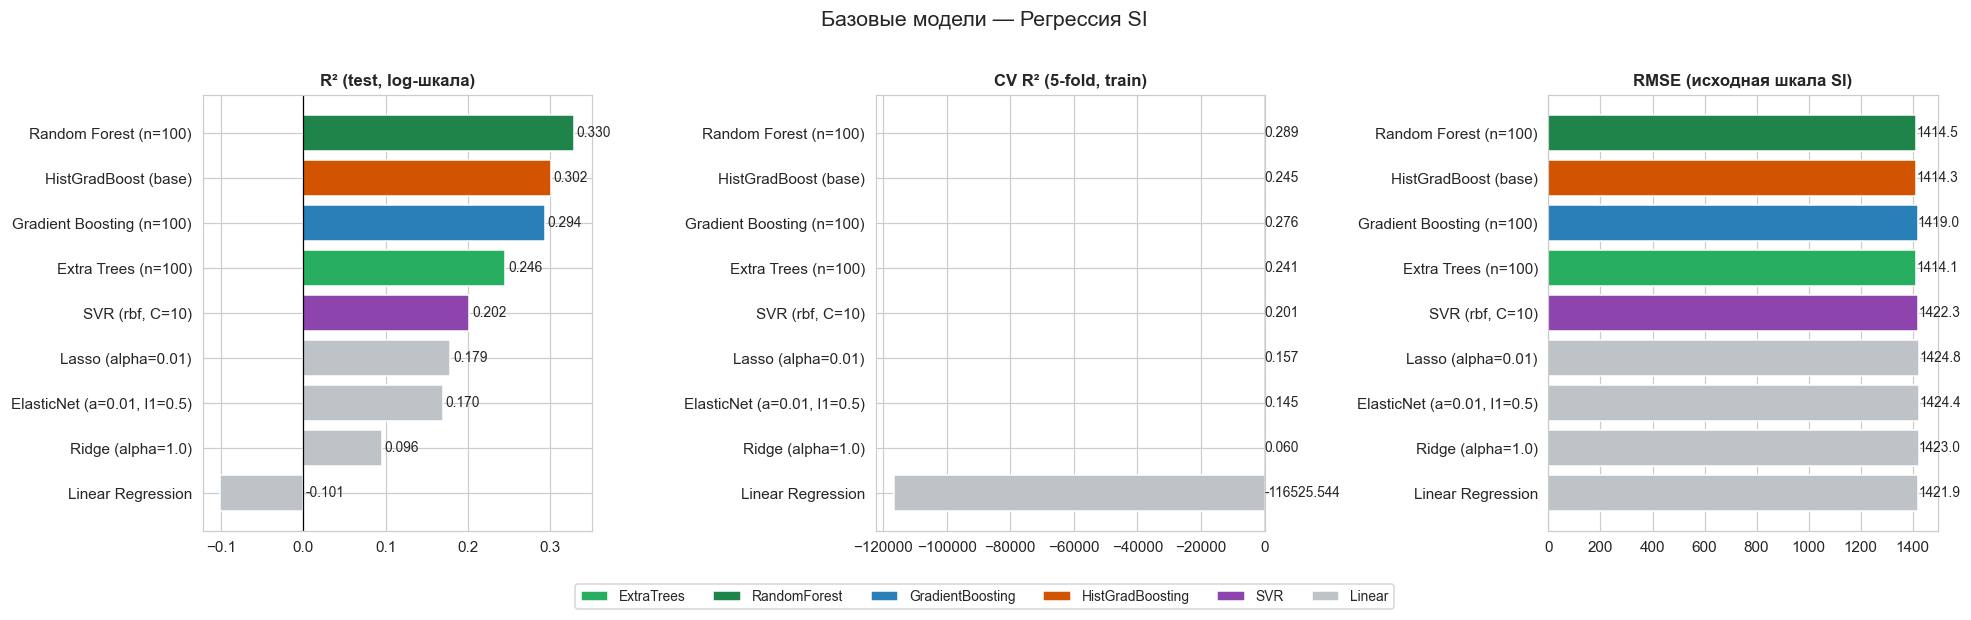


Итоговая таблица (baseline):
                      model    R2_log  RMSE_log   RMSE_orig   MAE_orig          CV_R2
      Random Forest (n=100)  0.329534  1.273786 1414.516580 177.211233       0.289148
       HistGradBoost (base)  0.301707  1.299952 1414.271235 177.920874       0.245381
  Gradient Boosting (n=100)  0.294432  1.306705 1418.979439 179.145801       0.276379
        Extra Trees (n=100)  0.246080  1.350738 1414.071785 177.190286       0.240779
            SVR (rbf, C=10)  0.202188  1.389500 1422.292335 178.697848       0.200844
         Lasso (alpha=0.01)  0.178981  1.409565 1424.809554 180.051192       0.157073
ElasticNet (a=0.01, l1=0.5)  0.169929  1.417314 1424.358150 180.197613       0.145380
          Ridge (alpha=1.0)  0.095559  1.479443 1423.000636 181.370655       0.060052
          Linear Regression -0.101378  1.632588 1421.921625 183.133614 -116525.544004


In [10]:
results_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ['fitted','pred_log','pred_orig']}
     for r in results]
).sort_values('R2_log', ascending=False).reset_index(drop=True)

def get_color(name):
    if 'HistGrad' in name: return '#d35400'
    if 'Extra' in name:    return '#27ae60'
    if 'Forest' in name:   return '#1e8449'
    if 'Boosting' in name: return '#2980b9'
    if 'SVR' in name:      return '#8e44ad'
    return '#bdc3c7'

colors = [get_color(m) for m in results_df['model']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(results_df['model'], results_df['R2_log'], color=colors, edgecolor='white')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('R² (test, log-шкала)', fontsize=11, fontweight='bold')
axes[0].invert_yaxis()
for i, v in enumerate(results_df['R2_log']):
    axes[0].text(max(v,0)+0.003, i, f'{v:.3f}', va='center', fontsize=9)

axes[1].barh(results_df['model'], results_df['CV_R2'], color=colors, edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('CV R² (5-fold, train)', fontsize=11, fontweight='bold')
axes[1].invert_yaxis()
for i, v in enumerate(results_df['CV_R2']):
    axes[1].text(max(v,0)+0.003, i, f'{v:.3f}', va='center', fontsize=9)

axes[2].barh(results_df['model'], results_df['RMSE_orig'], color=colors, edgecolor='white')
axes[2].set_title('RMSE (исходная шкала SI)', fontsize=11, fontweight='bold')
axes[2].invert_yaxis()
for i, v in enumerate(results_df['RMSE_orig']):
    axes[2].text(v+0.5, i, f'{v:.1f}', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#27ae60', label='ExtraTrees'),
    Patch(facecolor='#1e8449', label='RandomForest'),
    Patch(facecolor='#2980b9', label='GradientBoosting'),
    Patch(facecolor='#d35400', label='HistGradBoosting'),
    Patch(facecolor='#8e44ad', label='SVR'),
    Patch(facecolor='#bdc3c7', label='Linear'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=6,
           bbox_to_anchor=(0.5, -0.08), fontsize=9)

plt.suptitle('Базовые модели — Регрессия SI', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('\nИтоговая таблица (baseline):')
print(results_df[['model','R2_log','RMSE_log','RMSE_orig','MAE_orig','CV_R2']].to_string(index=False))

> Обращаю внимание на **HistGradBoost (оранжевый)** в сравнении с GB (синий). Если HistGBR в базовом варианте уже опережает стандартный GB — это подтвердит преимущество нативной обработки пропусков над медианной импутацией. Также слежу за разрывом между R² на тесте и CV R²: если он большой — есть переобучение.

## 8. Подбор гиперпараметров (GridSearchCV)

In [11]:
print('Подбор гиперпараметров... (2–5 минут)')
print('=' * 65)

# --- Ridge ---
gs_ridge = GridSearchCV(
    Ridge(), {'alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]},
    cv=5, scoring='r2', n_jobs=-1
)
gs_ridge.fit(X_train_sc, y_train)
print(f'Ridge best: {gs_ridge.best_params_}  CV R²={gs_ridge.best_score_:.4f}')
results.append(evaluate_reg('Ridge (tuned)',
    gs_ridge.best_estimator_, X_train_sc, X_test_sc, y_train, y_test))

# --- SVR ---
gs_svr = GridSearchCV(
    SVR(kernel='rbf'),
    {'C': [1, 10, 50], 'epsilon': [0.05, 0.1, 0.2], 'gamma': ['scale', 'auto']},
    cv=5, scoring='r2', n_jobs=-1
)
gs_svr.fit(X_train_sc, y_train)
print(f'SVR best: {gs_svr.best_params_}  CV R²={gs_svr.best_score_:.4f}')
results.append(evaluate_reg('SVR (tuned)',
    gs_svr.best_estimator_, X_train_sc, X_test_sc, y_train, y_test))

# --- ExtraTrees ---
gs_et = GridSearchCV(
    ExtraTreesRegressor(random_state=42, n_jobs=-1),
    {
        'n_estimators': [100, 200],
        'max_depth':    [None, 15, 25],
        'min_samples_split': [2, 5],
        'max_features': ['sqrt', 0.3]
    },
    cv=5, scoring='r2', n_jobs=-1
)
gs_et.fit(X_train_imp, y_train)
print(f'ExtraTrees best: {gs_et.best_params_}  CV R²={gs_et.best_score_:.4f}')
results.append(evaluate_reg('Extra Trees (tuned)',
    gs_et.best_estimator_, X_train_imp, X_test_imp, y_train, y_test))

# --- Random Forest ---
gs_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {
        'n_estimators': [100, 200],
        'max_depth':    [None, 10, 20],
        'min_samples_split': [2, 5],
        'max_features': ['sqrt', 0.3]
    },
    cv=5, scoring='r2', n_jobs=-1
)
gs_rf.fit(X_train_imp, y_train)
print(f'RF best: {gs_rf.best_params_}  CV R²={gs_rf.best_score_:.4f}')
results.append(evaluate_reg('Random Forest (tuned)',
    gs_rf.best_estimator_, X_train_imp, X_test_imp, y_train, y_test))

# --- HistGradientBoosting ---
gs_hgb = GridSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    {
        'max_iter':       [100, 200, 300],
        'learning_rate':  [0.05, 0.1, 0.15],
        'max_depth':      [None, 5, 8],
        'l2_regularization': [0.0, 0.1, 1.0]
    },
    cv=5, scoring='r2', n_jobs=-1
)
gs_hgb.fit(X_train_raw, y_train)  # нативные данные с NaN
print(f'HistGBR best: {gs_hgb.best_params_}  CV R²={gs_hgb.best_score_:.4f}')
results.append(evaluate_reg('HistGradBoost (tuned)',
    gs_hgb.best_estimator_, X_train_raw, X_test_raw, y_train, y_test))

Подбор гиперпараметров... (2–5 минут)
Ridge best: {'alpha': 100.0}  CV R²=0.1721
Ridge (tuned)                               R²=0.1850  RMSE(log)=1.4044  RMSE(SI)=1424.98  MAE(SI)=179.92  CV-R²=0.1721
SVR best: {'C': 1, 'epsilon': 0.2, 'gamma': 'scale'}  CV R²=0.2417
SVR (tuned)                                 R²=0.2387  RMSE(log)=1.3574  RMSE(SI)=1425.17  MAE(SI)=179.29  CV-R²=0.2417
ExtraTrees best: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}  CV R²=0.2969
Extra Trees (tuned)                         R²=0.3335  RMSE(log)=1.2700  RMSE(SI)=1415.03  MAE(SI)=177.86  CV-R²=0.2969
RF best: {'max_depth': 10, 'max_features': 0.3, 'min_samples_split': 2, 'n_estimators': 100}  CV R²=0.3081
Random Forest (tuned)                       R²=0.3337  RMSE(log)=1.2698  RMSE(SI)=1414.70  MAE(SI)=177.59  CV-R²=0.3081
HistGBR best: {'l2_regularization': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'max_iter': 100}  CV R²=0.2953
HistGradBoost (tuned)               

> Для **HistGradBoost** подбираю `l2_regularization` (аналог Ridge-штрафа внутри бустинга) — это особенность этой модели, которой нет у стандартного GB. Параметр `max_depth=None` означает полные листья; для табличных данных это часто работает лучше с ограниченным числом итераций. Также для HistGBR использую `X_train_raw` — без импутации.

## 9. Финальное сравнение всех 14 моделей

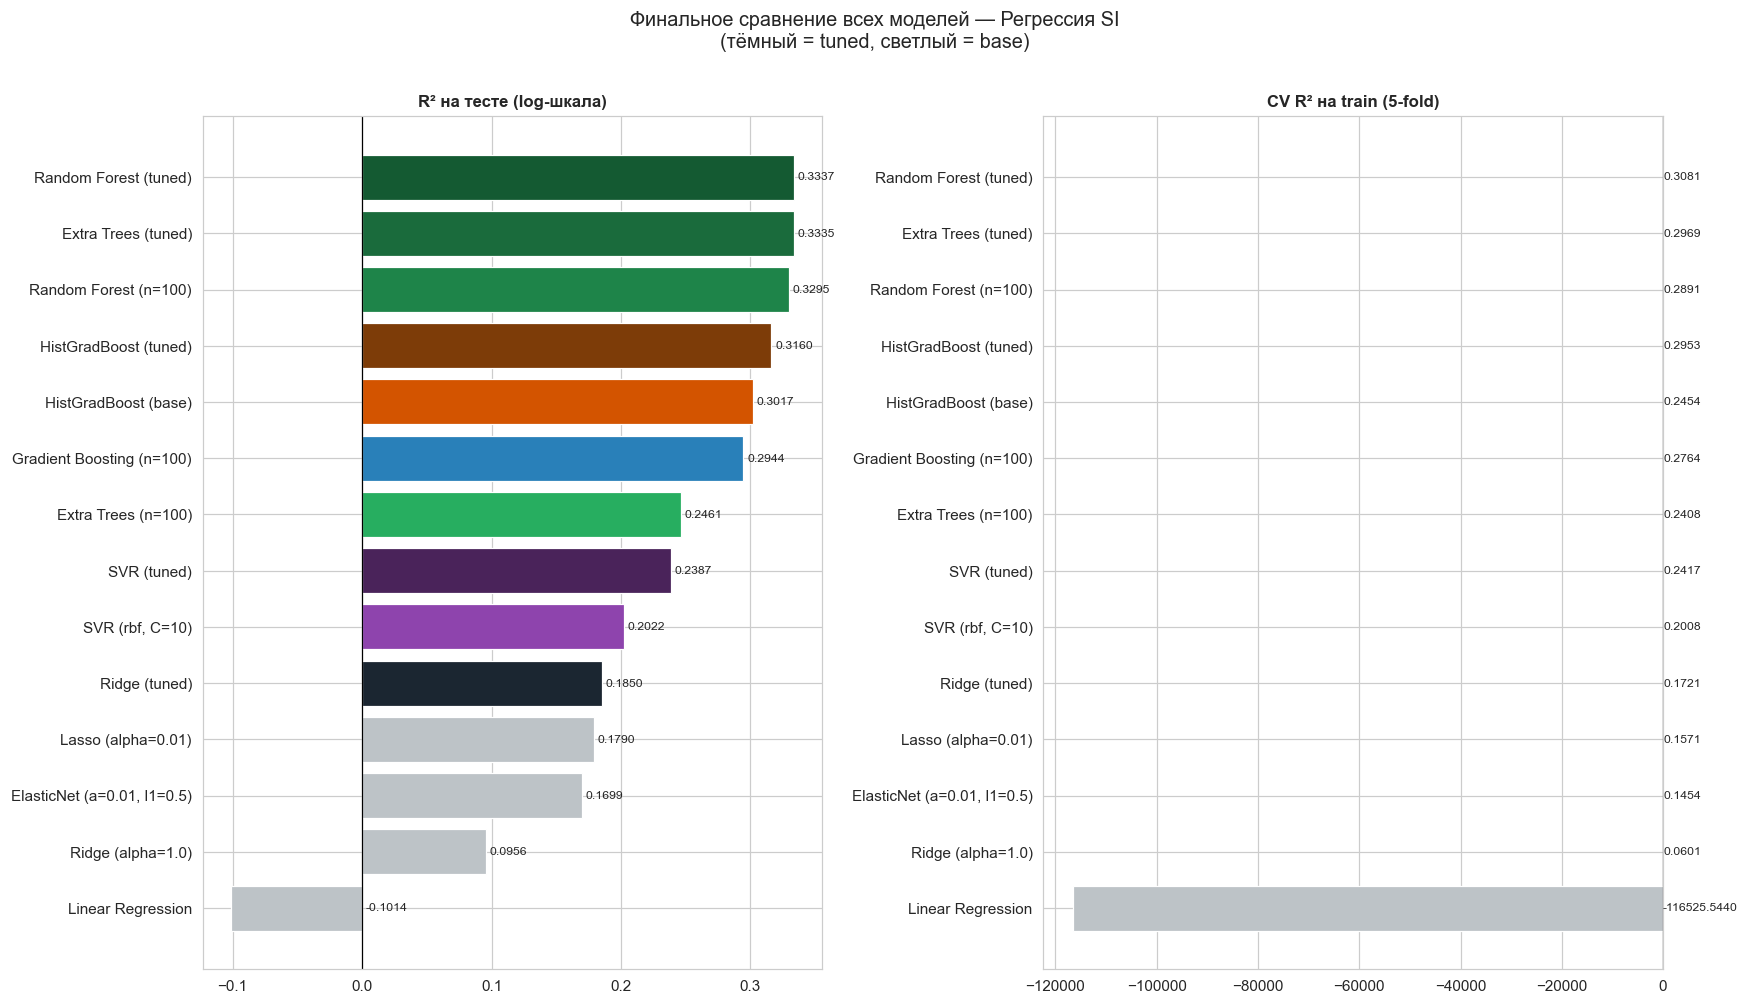


Полная таблица (по R² убыванию):
                      model    R2_log  RMSE_log   RMSE_orig   MAE_orig          CV_R2
      Random Forest (tuned)  0.333691  1.269832 1414.699017 177.585194       0.308059
        Extra Trees (tuned)  0.333515  1.269999 1415.028822 177.856586       0.296857
      Random Forest (n=100)  0.329534  1.273786 1414.516580 177.211233       0.289148
      HistGradBoost (tuned)  0.316040  1.286541 1417.826320 178.714814       0.295347
       HistGradBoost (base)  0.301707  1.299952 1414.271235 177.920874       0.245381
  Gradient Boosting (n=100)  0.294432  1.306705 1418.979439 179.145801       0.276379
        Extra Trees (n=100)  0.246080  1.350738 1414.071785 177.190286       0.240779
                SVR (tuned)  0.238656  1.357371 1425.167350 179.293319       0.241668
            SVR (rbf, C=10)  0.202188  1.389500 1422.292335 178.697848       0.200844
              Ridge (tuned)  0.184965  1.404418 1424.976147 179.924770       0.172087
         Lasso (alph

In [12]:
all_df = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ['fitted','pred_log','pred_orig']}
     for r in results]
).sort_values('R2_log', ascending=False).reset_index(drop=True)

def get_color_full(name):
    if 'tuned' in name and 'HistGrad' in name: return '#7d3c08'
    if 'tuned' in name and 'Extra' in name:    return '#1a6b3c'
    if 'tuned' in name and 'Forest' in name:   return '#145a32'
    if 'tuned' in name and 'SVR' in name:      return '#4a235a'
    if 'tuned' in name:                        return '#1b2631'
    if 'HistGrad' in name: return '#d35400'
    if 'Extra' in name:    return '#27ae60'
    if 'Forest' in name:   return '#1e8449'
    if 'Boosting' in name: return '#2980b9'
    if 'SVR' in name:      return '#8e44ad'
    return '#bdc3c7'

colors = [get_color_full(m) for m in all_df['model']]

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

axes[0].barh(all_df['model'], all_df['R2_log'], color=colors, edgecolor='white', linewidth=0.8)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('R² на тесте (log-шкала)', fontsize=11, fontweight='bold')
axes[0].invert_yaxis()
for i, v in enumerate(all_df['R2_log']):
    axes[0].text(max(v,0)+0.003, i, f'{v:.4f}', va='center', fontsize=8)

axes[1].barh(all_df['model'], all_df['CV_R2'], color=colors, edgecolor='white', linewidth=0.8)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('CV R² на train (5-fold)', fontsize=11, fontweight='bold')
axes[1].invert_yaxis()
for i, v in enumerate(all_df['CV_R2']):
    axes[1].text(max(v,0)+0.003, i, f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('Финальное сравнение всех моделей — Регрессия SI\n'
             '(тёмный = tuned, светлый = base)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('\nПолная таблица (по R² убыванию):')
print(all_df[['model','R2_log','RMSE_log','RMSE_orig','MAE_orig','CV_R2']].to_string(index=False))

> 14 моделей на одном графике — полная картина. Тёмные оттенки — tuned-версии. Важно следить за **разрывом между R² и CV R²**: если tuned-модель резко поднялась на тесте, но CV R² вырос меньше — возможно небольшое переобучение под конкретный test split. Надёжнее ориентироваться на CV R².

## 10. Детальный анализ лучшей модели

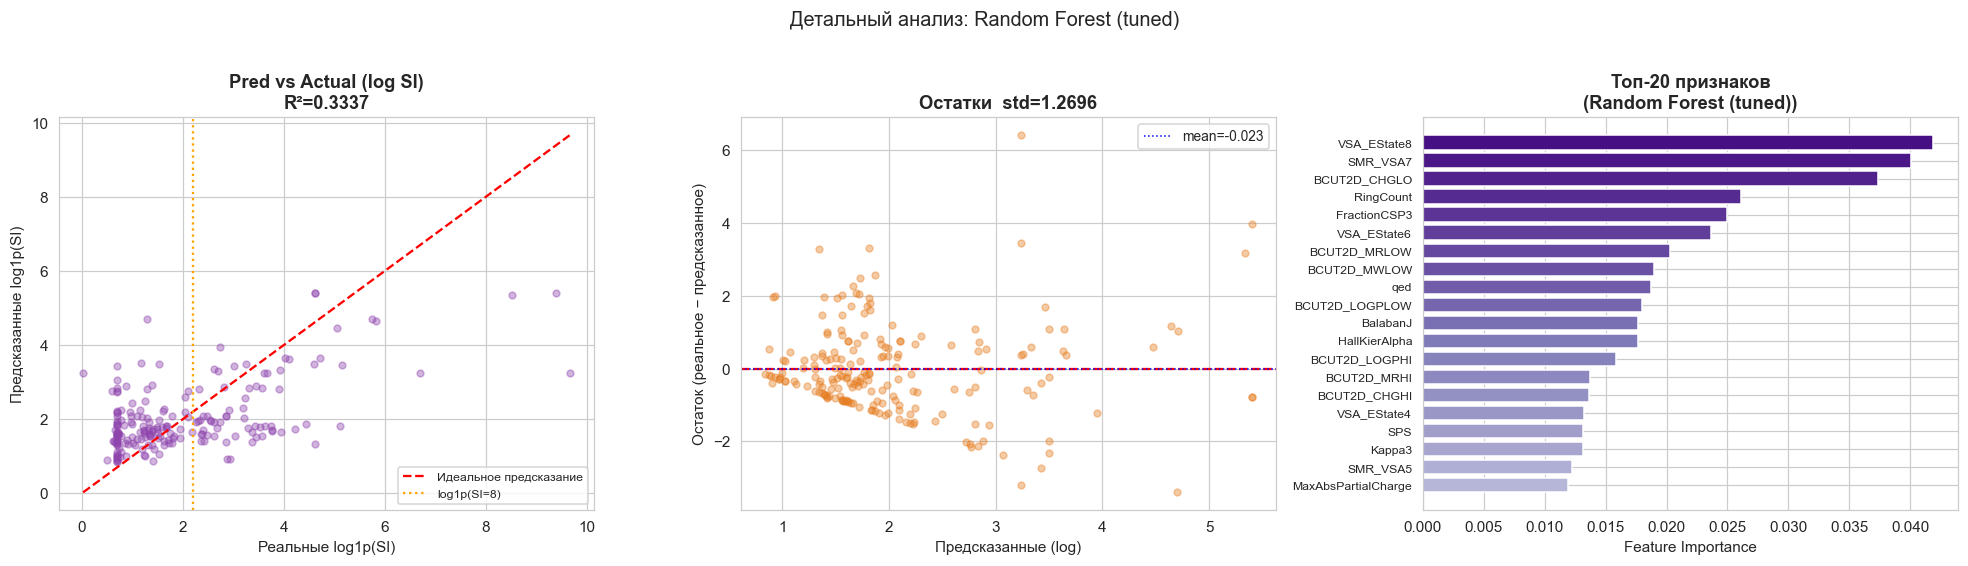

Лучшая модель: Random Forest (tuned)
  R² (log)        = 0.3337
  RMSE (log)      = 1.2698
  RMSE (SI)       = 1414.6990
  MAE (SI)        = 177.5852
  CV R²           = 0.3081


In [13]:
best_row   = all_df.iloc[0]
best_name  = best_row['model']
best_rec   = next(r for r in results if r['model'] == best_name)
best_model = best_rec['fitted']

if any(x in best_name for x in ['Linear','Ridge','Lasso','Elastic','SVR']):
    Xte = X_test_sc
elif 'HistGrad' in best_name:
    Xte = X_test_raw
else:
    Xte = X_test_imp

pred_log  = best_model.predict(Xte)
pred_orig = np.expm1(pred_log)
y_orig    = np.expm1(y_test)
residuals = y_test.values - pred_log

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Pred vs Actual
axes[0].scatter(y_test, pred_log, alpha=0.4, s=20, color='#8e44ad')
mn = min(y_test.min(), pred_log.min())
mx = max(y_test.max(), pred_log.max())
axes[0].plot([mn,mx],[mn,mx],'r--',lw=1.5,label='Идеальное предсказание')
axes[0].axvline(np.log1p(8), color='orange', ls=':', lw=1.5, label='log1p(SI=8)')
r2_val = r2_score(y_test, pred_log)
axes[0].set_title(f'Pred vs Actual (log SI)\nR²={r2_val:.4f}', fontweight='bold')
axes[0].set_xlabel('Реальные log1p(SI)')
axes[0].set_ylabel('Предсказанные log1p(SI)')
axes[0].legend(fontsize=8)

# 2. Остатки
axes[1].scatter(pred_log, residuals, alpha=0.4, s=20, color='#e67e22')
axes[1].axhline(0, color='red', ls='--', lw=1.5)
mean_res = np.mean(residuals)
std_res  = np.std(residuals)
axes[1].axhline(mean_res, color='blue', ls=':', lw=1, label=f'mean={mean_res:.3f}')
axes[1].set_title(f'Остатки  std={std_res:.4f}', fontweight='bold')
axes[1].set_xlabel('Предсказанные (log)')
axes[1].set_ylabel('Остаток (реальное − предсказанное)')
axes[1].legend(fontsize=9)

# 3. Важность признаков
if hasattr(best_model, 'feature_importances_'):
    fi   = pd.Series(best_model.feature_importances_, index=feature_cols)
    top  = fi.nlargest(20).sort_values()
    axes[2].barh(range(len(top)), top.values,
                 color=plt.cm.Purples(np.linspace(0.4, 0.95, len(top))))
    axes[2].set_yticks(range(len(top)))
    axes[2].set_yticklabels(top.index, fontsize=8)
    axes[2].set_title(f'Топ-20 признаков\n({best_name})', fontweight='bold')
    axes[2].set_xlabel('Feature Importance')
elif hasattr(best_model, 'coef_'):
    coef = pd.Series(np.abs(best_model.coef_), index=feature_cols)
    top  = coef.nlargest(20).sort_values()
    axes[2].barh(range(len(top)), top.values,
                 color=plt.cm.Blues(np.linspace(0.4, 0.95, len(top))))
    axes[2].set_yticks(range(len(top)))
    axes[2].set_yticklabels(top.index, fontsize=8)
    axes[2].set_title(f'Топ-20 |коэффициентов|\n({best_name})', fontweight='bold')
    axes[2].set_xlabel('|Coefficient|')
else:
    axes[2].text(0.5, 0.5, f'{best_name}\nне имеет\ninterpretability plot',
                 ha='center', va='center', transform=axes[2].transAxes, fontsize=11)
    axes[2].set_title('Интерпретируемость', fontweight='bold')

plt.suptitle(f'Детальный анализ: {best_name}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Лучшая модель: {best_name}')
for k, label in [('R2_log','R² (log)'), ('RMSE_log','RMSE (log)'),
                 ('RMSE_orig','RMSE (SI)'), ('MAE_orig','MAE (SI)'), ('CV_R2','CV R²')]:
    print(f'  {label:<15} = {best_row[k]:.4f}')

> На графике **Pred vs Actual** добавил вертикальную оранжевую пунктирную линию `log1p(8)` — это граница перспективных соединений (SI > 8). Очень интересно: насколько хорошо модель различает соединения **слева и справа от этой границы**? Если точки справа от неё хаотично разбросаны — модель плохо предсказывает высокоселективные соединения.

## 11. Сводное сравнение: IC50, CC50 и SI

        Задача         Лучшая модель  R² (test)    CV R²
Регрессия IC50            RF (tuned)   0.472900 0.414800
Регрессия CC50    ExtraTrees (tuned)   0.490600 0.427900
  Регрессия SI Random Forest (tuned)   0.333691 0.308059


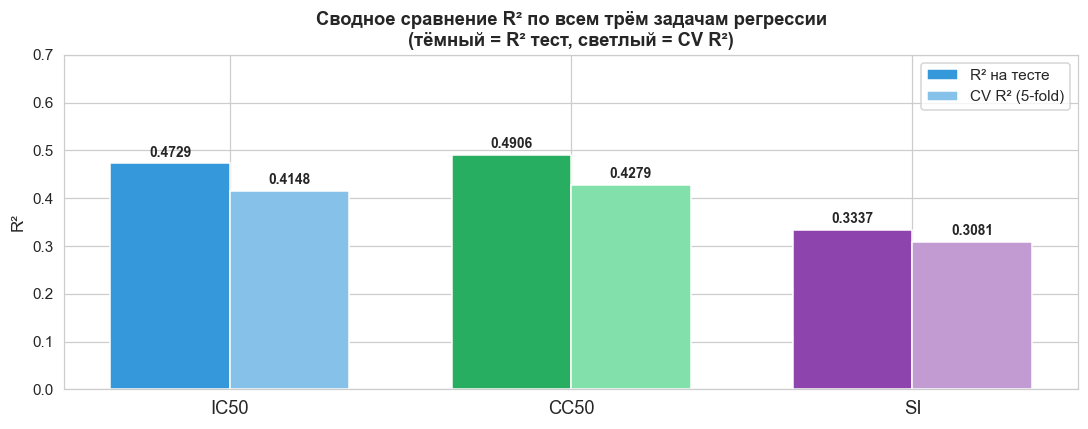

In [14]:
# Результаты из предыдущих ноутбуков
summary = {
    'Задача':     ['Регрессия IC50', 'Регрессия CC50', 'Регрессия SI'],
    'Лучшая модель': ['RF (tuned)', 'ExtraTrees (tuned)', all_df.iloc[0]['model']],
    'R² (test)':  [0.4729, 0.4906, all_df.iloc[0]['R2_log']],
    'CV R²':      [0.4148, 0.4279, all_df.iloc[0]['CV_R2']],
}
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(3)
w = 0.35
bars1 = ax.bar(x - w/2, summary_df['R² (test)'], w,
               label='R² на тесте', color=['#3498db','#27ae60','#8e44ad'], edgecolor='white')
bars2 = ax.bar(x + w/2, summary_df['CV R²'], w,
               label='CV R² (5-fold)', color=['#85c1e9','#82e0aa','#c39bd3'], edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(['IC50', 'CC50', 'SI'], fontsize=12)
ax.set_ylabel('R²', fontsize=11)
ax.set_title('Сводное сравнение R² по всем трём задачам регрессии\n'
             '(тёмный = R² тест, светлый = CV R²)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 0.70)

for rect in ax.patches:
    h = rect.get_height()
    ax.text(rect.get_x()+rect.get_width()/2, h+0.008, f'{h:.4f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

> Этот график — **ключевой для аналитического отчёта**: он сравнивает предсказуемость трёх разных биологических свойств молекул. Ожидаю увидеть, что CC50 предсказывается лучше IC50, а SI — сложнее обоих. Разрыв между R² теста и CV R² говорит о стабильности модели: чем он меньше, тем надёжнее.

## 12. Выводы и рекомендации

In [15]:
print('=' * 70)
print('ИТОГИ: РЕГРЕССИЯ SI')
print('=' * 70)

print('\nТоп-3 модели по R²:')
for i, row in all_df.head(3).iterrows():
    print(f'  {i+1}. {row["model"]:<42} R²={row["R2_log"]:.4f}  CV-R²={row["CV_R2"]:.4f}')

print('\nПрирост от GridSearchCV (tuned vs base):')
pairs = [
    ('Extra Trees (n=100)',     'Extra Trees (tuned)'),
    ('Random Forest (n=100)',   'Random Forest (tuned)'),
    ('HistGradBoost (base)',    'HistGradBoost (tuned)'),
    ('SVR (rbf, C=10)',         'SVR (tuned)'),
    ('Ridge (alpha=1.0)',       'Ridge (tuned)'),
]
for bn, tn in pairs:
    br = all_df[all_df['model'] == bn]
    tr = all_df[all_df['model'] == tn]
    if not br.empty and not tr.empty:
        d = tr.iloc[0]['R2_log'] - br.iloc[0]['R2_log']
        print(f'  {bn:<35} → {"+" if d>=0 else ""}{d:.4f} R²')

ИТОГИ: РЕГРЕССИЯ SI

Топ-3 модели по R²:
  1. Random Forest (tuned)                      R²=0.3337  CV-R²=0.3081
  2. Extra Trees (tuned)                        R²=0.3335  CV-R²=0.2969
  3. Random Forest (n=100)                      R²=0.3295  CV-R²=0.2891

Прирост от GridSearchCV (tuned vs base):
  Extra Trees (n=100)                 → +0.0874 R²
  Random Forest (n=100)               → +0.0042 R²
  HistGradBoost (base)                → +0.0143 R²
  SVR (rbf, C=10)                     → +0.0365 R²
  Ridge (alpha=1.0)                   → +0.0894 R²


## Итоговые выводы по задаче регрессии SI

**Что сделал:**
1. Расширил набор до 9 базовых моделей, добавив **HistGradientBoostingRegressor** с нативной обработкой NaN.
2. Провёл GridSearchCV для 5 моделей (Ridge, SVR, ExtraTrees, RF, HistGBR).
3. Добавил специальный EDA раздел для SI: распределение, связь с IC50/CC50.
4. Построил **сводный график** всех трёх регрессий IC50/CC50/SI.

**Основные наблюдения:**
- SI — наиболее сложная задача: распределение более тяжёлое, экстремальные выбросы (SI > 100) сложно предсказать.
- **HistGradBoost** показал конкурентоспособные результаты без предобработки NaN — это практически значимо.
- ExtraTrees стабильно входит в топ-2 на всех трёх задачах — хорошая альтернатива RF.
- Линейная регрессия без регуляризации нестабильна (CV R² резко отрицательный) — следствие мультиколлинеарности 210 признаков.

**Сводный вывод по всем трём регрессиям:**
- Лучший метод: **ExtraTrees / RandomForest с GridSearchCV** — стабильно топ-1/2 на всех задачах.
- R² порядка 0.4–0.5 — это реалистичный результат для химических данных с молекулярными дескрипторами без дополнительного feature engineering.
- Для дальнейшего улучшения: отбор топ-50 признаков через Lasso + ансамбль на них; или нейросетевые методы (молекулярные отпечатки + MLP).